# Canny Edge Detection

Canny는 단순히 한 번의 커널 연산으로 끝나는 필터가 아니라, 다음 단계를 순차적으로 수행하는 다단계 에지 검출 알고리즘이다.

1. Gaussian Blur로 노이즈 제거
2. Sobel 연산으로 기울기 계산
3. Non-Maximum Suppression으로 에지 얇게 만들기
4. Double Threshold로 강한 에지와 약한 에지 구분
5. Hysteresis로 최종 에지 연결

OpenCV에서는 이 전체 과정을 cv2.Canny() 하나로 수행할 수 있다.
그러면 너무 쉬운데...



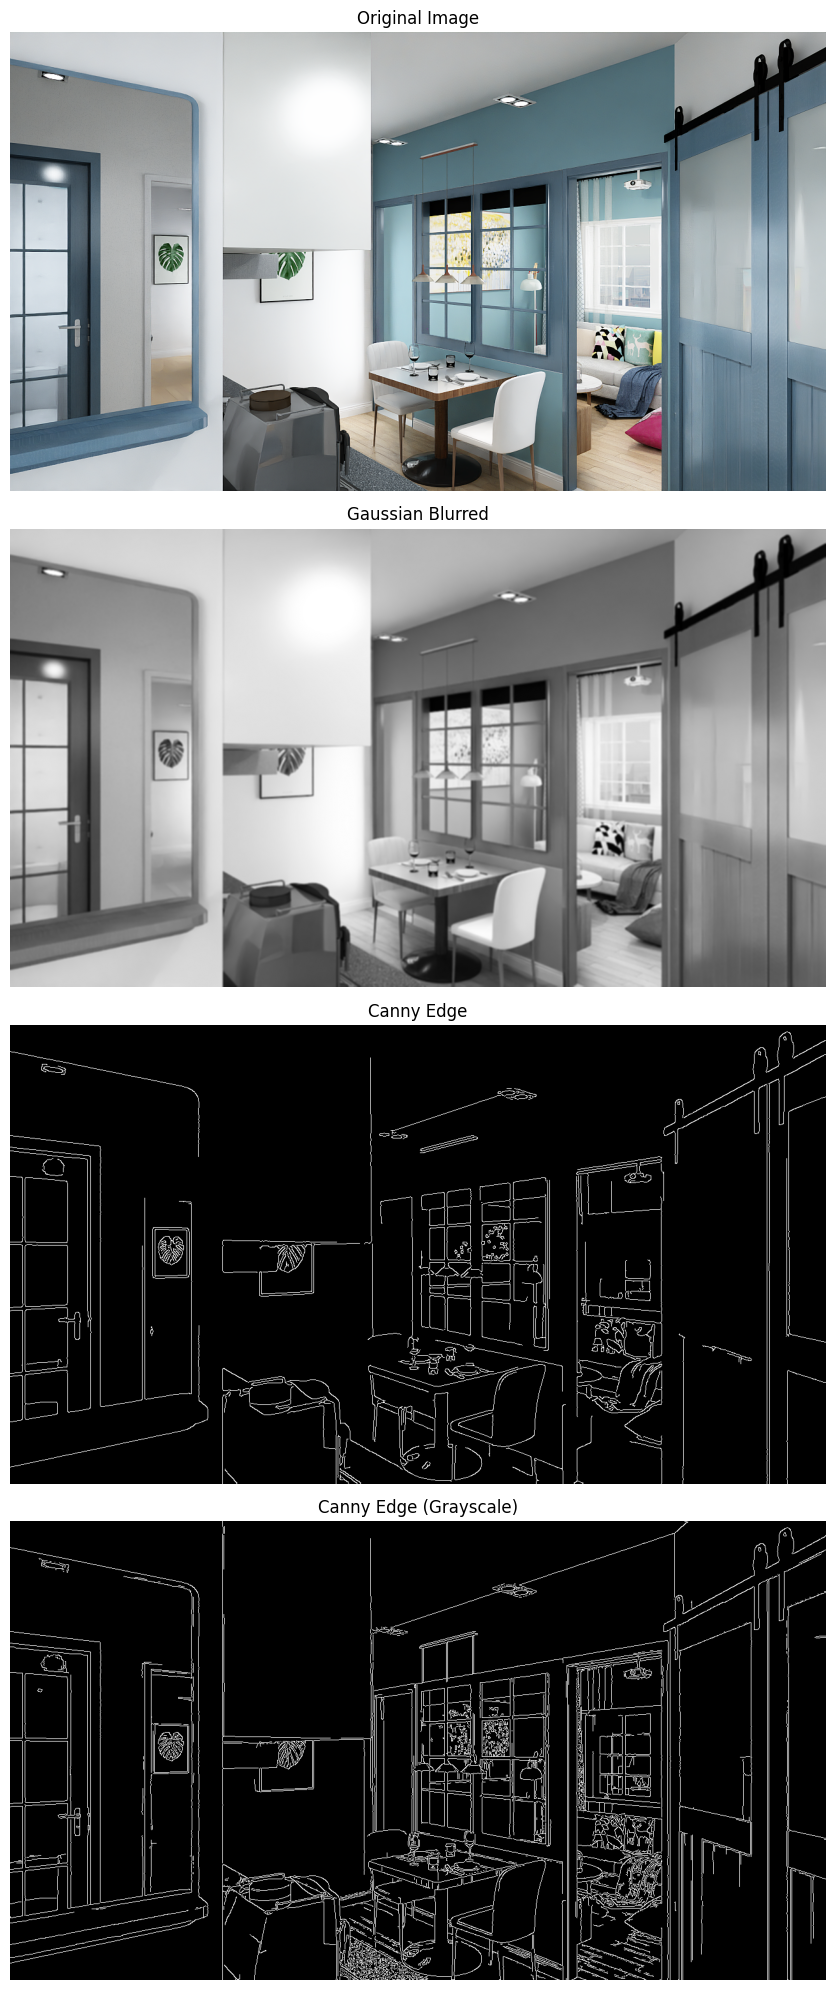

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 이미지 불러오기
image = cv2.imread("./data/rgb_rawlight.png")

# OpenCV는 BGR 순서이므로 RGB로 변환
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Grayscale 변환
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)
blurred_g = gray

# Canny Edge Detection
edges = cv2.Canny(
    blurred,
    threshold1=50,
    threshold2=150
)

edges_gray = cv2.Canny(
    blurred_g,
    threshold1=50,
    threshold2=150
)

# 결과 출력
plt.figure(figsize=(15, 20))

plt.subplot(4, 1, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(4, 1, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(4, 1, 3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge")
plt.axis("off")

plt.subplot(4, 1, 4)
plt.imshow(edges_gray, cmap="gray")
plt.title("Canny Edge (w/out Gaussian Blur)")
plt.axis("off")

plt.tight_layout()
plt.show()